In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab05.ipynb")

<img src="data8logo.png" alt="Data 8 Logo" style="width: 15%; float: right; padding: 1%; margin-right: 2%;"/>

# Lab 5: Simulations

Welcome to Lab 5! The data used in this lab will contain salary data and other statistics for basketball players from the 2023-2024 NBA season. This data was collected from the following sports analytic sites: [Basketball Reference](https://www.basketball-reference.com/leagues/NBA_2024_per_game.html) and [Hoops Hype](https://hoopshype.com/salaries/players/2023-2024/).

**Recommended Reading**:

* [Iteration](https://www.inferentialthinking.com/chapters/09/2/Iteration.html)
* [Simulations](https://www.inferentialthinking.com/chapters/09/3/Simulation.html)
* [Randomness](https://www.inferentialthinking.com/chapters/09/Randomness.html)
* [Python Reference](https://www.data8.org/fa24/reference/)

**Getting help on lab**: Whenever you feel stuck or need some further clarification, find a GSI or tutor, and they'll be happy to help!

As a reminder, here are the policies for getting full credit:

1. For students enrolled in in-person <span style="color: #BC412B">**Regular Labs**</span>, you will receive 80% lab credit by **attending** lab discussion, 20% lab credit for passing all test cases, and submitting it to Gradescope by **5pm on the Friday the same week it was released**.

2. For students enrolled in <span style="color: #04888B">**Self Service**</span>, you will receive full lab credit by **completing** the notebook, passing all test cases, and **submitting** it to Gradescope by **5pm on the Friday the same week it was released**.

**Submission**: Once you’re finished, run all cells besides the last one, select File > Save Notebook, and then execute the final cell. The result will contain a zip file that you can use to submit on Gradescope.

Let's begin by setting up the tests and imports by running the cell below.

In [2]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 1. Nachos and Conditionals

In Python, the boolean is a data type with only two possible values:  `True` and `False`. Expressions containing comparison operators such as `<` (less than), `>` (greater than), and `==` (equal to) evaluate to Boolean values. A list of common comparison operators can be found below!

| Comparison         | Operator | True Example | False Example |
|--------------------|----------|--------------|---------------|
| Less than          | `<`      | 2 < 3        | 2 < 2         |
| Greater than       | `>`      | 3 > 2        | 3 > 3         |
| Less than or equal | `<=`     | 2 <= 2       | 3 <= 2        |
| Greater or equal   | `>=`     | 3 >= 3       | 2 >= 3        |
| Equal              | `==`     | 3 == 3       | 3 == 2        |
| Not equal          | `!=`     | 3 != 2       | 2 != 2        |


Run the cell below to see an example of a comparison operator in action.

In [3]:
3 > (1 + 1)

True

We can even assign the result of a comparison operation to a variable. Note that `==` and `=` are **not** the same!

In [4]:
result = 10 / 2 == 5
result

True

Just like arithmetic operators can be applied on every item of an array, comparison operators can also be used on arrays to compare an entire array with some value. The output of this comparison is an array of boolean values.

In [5]:
make_array(1, 5, 7, 8, 3, -1) > 3

array([False,  True,  True,  True, False, False], dtype=bool)

One day, when you come home after a long week, you see a hot bowl of nachos waiting on the dining table! Let's say that whenever you take a nacho from the bowl, it will either have only **cheese**, only **salsa**, **both** cheese and salsa, or **neither** cheese nor salsa (a sad tortilla chip indeed). 

Let's try and simulate taking nachos from the bowl at random using the function, `np.random.choice(...)`.

### `np.random.choice`

`np.random.choice` picks one item at random from the given array. It is equally likely to pick any of the items. Run the cell below several times, and observe how the results change. _Tip:_ To keep running a cell multiple times you can use the keyboard shortcut `ctrl` + `return`. 

In [6]:
nachos = make_array('cheese', 'salsa', 'both', 'neither')
np.random.choice(nachos)

'cheese'

To repeat this process multiple times, pass in an int `n` as the second argument to return `n` different random choices. By default, `np.random.choice` samples **with replacement** and returns an *array* of items. Sampling **with replacement** means that after an element is drawn, it is replaced back to where you are sampling from and can be drawn again in the future. If we sample `n` times with replacement, each time, every element has an equal chance of being selected.

Run the next cell to see an example of sampling with replacement 10 times from the `nachos` array.

In [7]:
np.random.choice(nachos, 10)

array(['neither', 'both', 'salsa', 'both', 'neither', 'both', 'both',
       'salsa', 'salsa', 'neither'],
      dtype='<U7')

To count the number of times a certain type of nacho is randomly chosen, we can use `np.count_nonzero`

### `np.count_nonzero`

`np.count_nonzero` counts the number of non-zero values that appear in an array. When an array of boolean values are passed through the function, it will count the number of `True` values (remember that in Python, **`True` is coded as 1 and `False` is coded as 0.**)

Run the next cell to see an example that uses `np.count_nonzero`.

In [8]:
np.count_nonzero(make_array(True, False, False, True, True))

3

---

**Question 1.1** Assume we took ten nachos at random, and stored the results in an array called `ten_nachos` as done below. **Find the number of nachos with only cheese using code** (do not manually enter the final answer).  

*Hint:* Our solution involves a comparison operator (e.g. `==`, `<`, ...) and the `np.count_nonzero` method.


In [12]:
ten_nachos = make_array('neither', 'cheese', 'both', 'both', 'cheese', 'salsa', 'both', 'neither', 'cheese', 'both')
number_cheese = np.count_nonzero(ten_nachos == 'cheese')
number_cheese

3

In [13]:
grader.check("q11")

q11 results: All test cases passed!

**Conditional Statements**

A conditional statement is a multi-line statement that allows Python to choose among different alternatives based on the truth value of an expression.

Here is a basic example.

```python
def sign(x):
    if x > 0:
        return 'Positive'
    else:
        return 'Negative'
```

If the input `x` is greater than `0`, we return the string `'Positive'`. Otherwise, we return `'Negative'`.

If we want to test multiple conditions at once, we use the following general format.

```python
if <if expression>:
    <if body>
elif <elif expression 0>:
    <elif body 0>
elif <elif expression 1>:
    <elif body 1>
...
else:
    <else body>
```

Only the body for the first conditional expression that is true will be evaluated. Each `if` and `elif` expression is evaluated and considered in order, starting at the top. `elif` can only be used if an `if` clause precedes it. As soon as a true value is found, the corresponding body is executed, and the rest of the conditional statement is skipped. If none of the `if` or `elif` expressions are true, then the `else body` is executed. 

For more examples and explanation, refer to the section on conditional statements [here](https://inferentialthinking.com/chapters/09/1/Conditional_Statements.html).

---

**Question 1.2** Complete the following conditional statement so that the string `'More please'` is assigned to the variable `say_please` if the number of nachos with cheese in `ten_nachos` is less than `5`. Use the if statement to do this (do not directly reassign the variable `say_please`). 

*Hint*: You should be using `number_cheese` from Question 1.


In [15]:
say_please = '?'

if number_cheese < 5:
    say_please = 'More please'
say_please

'More please'

In [16]:
grader.check("q12")

q12 results: All test cases passed!

---

**Question 1.3** Write a function called `nacho_reaction` that returns a reaction (as a string) based on the type of nacho passed in as an argument. Use the table below to match the nacho type to the appropriate reaction.

|Nacho Type|Reaction|
|---|---|
|cheese|Cheesy!|
|salsa|Spicy!|
|both|Wow!|
|neither|Meh.|

*Hint:* If you're failing the test, double check the spelling of your reactions.


In [18]:
def nacho_reaction(nacho):
    if nacho == "cheese":
        return "Cheesy!"
    if nacho == "salsa":
        return "Spicy!"
    if nacho == "both":
        return "Wow!"
    if nacho == "neither":
        return "Meh."

spicy_nacho = nacho_reaction('salsa')
spicy_nacho

'Spicy!'

In [19]:
grader.check("q13")

q13 results: All test cases passed!

---

**Question 1.4** Create a table `ten_nachos_reactions` that consists of the nachos in `ten_nachos` as well as the reactions for each of those nachos. The columns should be called `Nachos` and `Reactions`.

*Hint:* Consider using the `apply` method, which returns an array.


In [22]:
ten_nachos_tbl = Table().with_column('Nachos', ten_nachos)
ten_nachos_reactions = ten_nachos_tbl.with_column(
    'Reactions', ten_nachos_tbl.apply(nacho_reaction,'Nachos'))
ten_nachos_reactions

Nachos,Reactions
neither,Meh.
cheese,Cheesy!
both,Wow!
both,Wow!
cheese,Cheesy!
salsa,Spicy!
both,Wow!
neither,Meh.
cheese,Cheesy!
both,Wow!


In [23]:
grader.check("q14")

q14 results: All test cases passed!

---

**Question 1.5** Using code, find the number of 'Wow!' reactions for the nachos in `ten_nachos_reactions`.

In [30]:
number_wow_reactions = ten_nachos_reactions.where('Reactions', are.equal_to('Wow!')).num_rows
number_wow_reactions

4

In [31]:
grader.check("q15")

q15 results: All test cases passed!

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 2. Simulations and For Loops
Using a `for` statement, we can perform a task multiple times. This is known as iteration. The general structure of a for loop is:

`for <placeholder> in <array>:` followed by indented lines of code that are repeated for each element of the `array` being iterated over. You can read more about for loops [here](https://www.inferentialthinking.com/chapters/09/2/Iteration.html). 

**NOTE:** We often use `i` as the `placeholder` in our class examples, but you could name it anything! Some examples can be found below.

One use of iteration is to loop through a set of values. For instance, we can print out all of the colors of the rainbow.

In [32]:
rainbow = make_array("red", "orange", "yellow", "green", "blue", "indigo", "violet")

for color in rainbow:
    print(color)

red
orange
yellow
green
blue
indigo
violet


We can see that the indented part of the `for` loop, known as the body, is executed once for each item in `rainbow`. The name `color` is assigned to the next value in `rainbow` at the start of each iteration. Note that the name `color` is arbitrary; we could easily have named it something else. Whichever name we pick, we need to use it consistently throughout the `for` loop. 

In [33]:
for another_name in rainbow:
    print(another_name)

red
orange
yellow
green
blue
indigo
violet


In general, however, we would like the variable name to be somewhat informative. 

---

**Question 2.1** In the following cell, we've loaded the text of _Pride and Prejudice_ by Jane Austen, split it into individual words, and stored these words in an array `p_and_p_words`. Using a `for` loop, assign `longer_than_five` to the number of words in the novel that are more than 5 letters long.

*Hint*: You can find the number of letters in a word with the `len` function.

*Hint*: How can you use `longer_than_five` to keep track of the number of words that are more than five letters long?


In [37]:
austen_string = open('Austen_PrideAndPrejudice.txt', encoding='utf-8').read()
p_and_p_words = np.array(austen_string.split())

longer_than_five = 0

for word in p_and_p_words:
    if(len(word) > 5):
        longer_than_five += 1
longer_than_five

35453

In [38]:
grader.check("q21")

q21 results: All test cases passed!

Another way we can use `for` loops is to repeat lines of code many times. Recall the structure of a `for` loop: 

`for <placeholder> in <array>:` followed by indented lines of code that are repeated for each element of the array being iterated over. 

Sometimes, we don't care about what the value of the placeholder is. We instead take advantage of the fact that the `for` loop will repeat as many times as the length of our array. In the following cell, we iterate through an array of length 5 and print out "Hello, world!" in each iteration, but we don't need to use the placeholder `i` in the body of our `for` loop. 

In [39]:
for i in np.arange(5):
    print("Hello, world!")

Hello, world!
Hello, world!
Hello, world!
Hello, world!
Hello, world!


---

**Question 2.2** Using a simulation with 10,000 trials, assign `num_different` to the **number** of times, in 10,000 trials, that two words picked uniformly at random (with replacement) from Pride and Prejudice have different lengths. 

*Hint 1*: What function did we use in section 1 to sample at random with replacement from an array? 

*Hint 2*: Remember that `!=` checks for non-equality between two items.


In [44]:
trials = 10000
num_different = 0 

for _ in np.arange(trials):
    words = np.random.choice(p_and_p_words, 2)
    if(len(words.item(0)) != len(words.item(1))): num_different += 1

num_different

8608

In [43]:
grader.check("q22")

q22 results: All test cases passed!

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 3. Sampling Basketball Data

We will now introduce the topic of sampling, which we’ll be discussing in more depth in this week’s lectures. We’ll guide you through this code, but if you wish to read more about different kinds of samples before attempting this question, you can check out [section 10 of the textbook](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html).

Run the cell below to load `full_data` which contains nba player and salary data that we will use for our sampling.

In [45]:
full_data = Table.read_table("nba.csv")

# The show method immediately displays the contents of a table.
# Think of it like the `print()` function
full_data.show(10)

Player,Salary Rank,Salary,Player Rank,Age,Team,Position,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
Stephen Curry,1,51915615,11,35,GSW,PG,74,4.5,5.1,0.7,0.4,2.8,26.4
Kevin Durant,2,47649433,7,35,PHO,PF,75,6.6,5,0.9,1.2,3.3,27.1
Joel Embiid,3,47607350,1,29,PHI,C,39,11,5.6,1.2,1.7,3.8,34.7
LeBron James,3,47607350,15,39,LAL,PF,71,7.3,8.3,1.3,0.5,3.5,25.7
Bradley Beal,6,46741590,63,30,PHO,SG,53,4.4,5,1,0.5,2.5,18.2
Damian Lillard,7,45640084,20,33,MIL,PG,73,4.4,7,1,0.2,2.6,24.3
Giannis Antetokounmpo,7,45640084,3,29,MIL,PF,73,11.5,6.5,1.2,1.1,3.4,30.4
Kawhi Leonard,7,45640084,25,32,LAC,SF,68,6.1,3.6,1.6,0.9,1.8,23.7
Paul George,7,45640084,31,33,LAC,PF,74,5.2,3.5,1.5,0.5,2.1,22.6
Jimmy Butler,11,45183960,44,34,MIA,PF,60,5.3,5,1.3,0.3,1.7,20.8


Imagine that we had gotten data on only a smaller subset of the players. For 525 players, it's not so unreasonable to expect to see all the data, but usually we aren't so lucky. 

If we want to make estimates about a certain numerical property of the population, we may have to come up with these estimates based only on a smaller sample. The numerical property of the population is known as a **parameter**, and the estimate is known as a **statistic** (e.g. the mean or median). Whether these estimates are useful or not often depends on how the sample was gathered. We have prepared some example sample datasets to see how they compare to the full NBA dataset. Later we'll ask you to create your own samples to see how they behave.

To save typing and increase the clarity of your code, we will package the analysis code into a few functions. This will be useful in the rest of the lab as we will repeatedly need to create histograms and collect summary statistics from that data.

We've defined the `histograms` function below, which takes a table with columns `Age` and `Salary` and draws a histogram for each one. It uses bin widths of 1 year for `Age` and $1,000,000 for `Salary`.

Two histograms should be displayed below


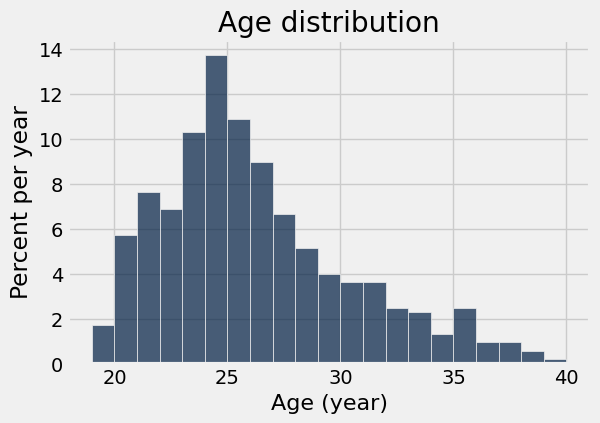

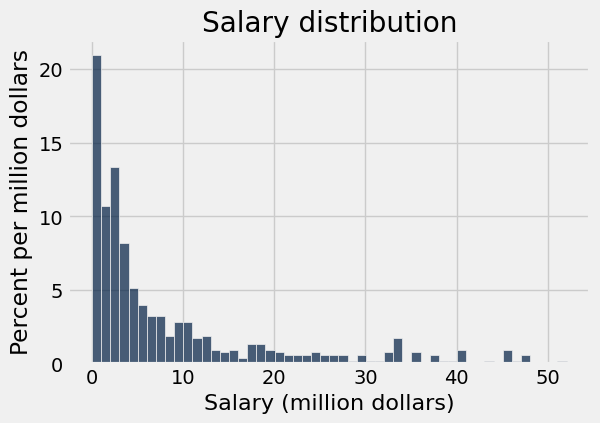

In [46]:
def histograms(t):
    ages = t.column('Age')
    salaries = t.column('Salary')/1000000
    t1 = t.drop('Salary').with_column('Salary', salaries)
    age_bins = np.arange(min(ages), max(ages) + 2, 1) 
    salary_bins = np.arange(min(salaries), max(salaries) + 1, 1)
    t1.hist('Age', bins=age_bins, unit='year')
    plt.title('Age distribution')
    t1.hist('Salary', bins=salary_bins, unit='million dollars')
    plt.title('Salary distribution') 
    
histograms(full_data)
print('Two histograms should be displayed below')

---

**Question 3.1**. Create a function called `compute_statistics` that takes a table containing an "Age" column and a "Salary" column and:
- Draws a histogram of ages
- Draws a histogram of salaries
- Returns a two-element array containing the average age and average salary (in that order)

You can call the `histograms` function to draw the histograms!


array([  2.57371429e+01,   8.45035460e+06])

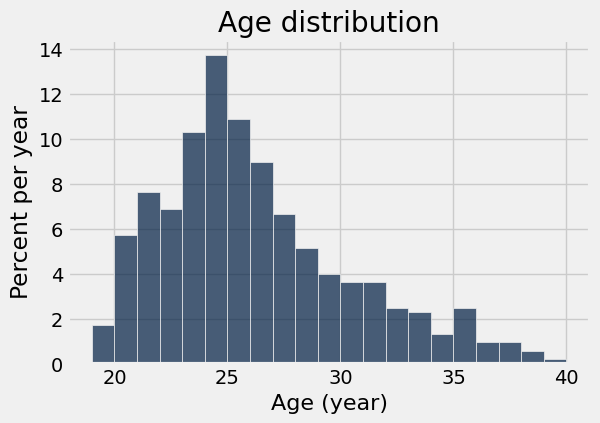

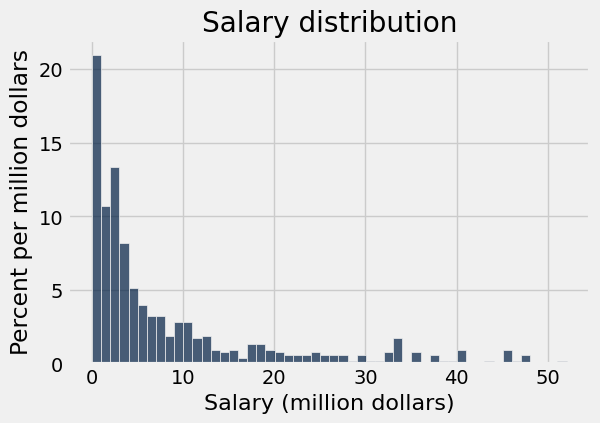

In [52]:
def compute_statistics(age_and_salary_data):
    age = age_and_salary_data.column('Age')
    salary = age_and_salary_data.column('Salary')
    histograms(age_and_salary_data)
    return make_array(np.mean(age), np.mean(salary))
    

full_stats = compute_statistics(full_data)
full_stats

In [53]:
grader.check("q31")

q31 results: All test cases passed!

### Simple random sampling
A more justifiable approach is to sample uniformly at random from the players.  In a **simple random sample (SRS) without replacement**, we ensure that each player is selected at most once. Imagine writing down each player's name on a card, putting the cards in an box, and shuffling the box.  Then, pull out cards one by one and set them aside, stopping when the specified sample size is reached.

### Producing simple random samples
Sometimes, it’s useful to take random samples even when we have the data for the whole population. It helps us understand sampling accuracy.

### `sample`

The table method `sample` produces a random sample from the table. By default, it draws at random **with replacement** from the rows of a table. Sampling with replacement means for any row selected randomly, there is a chance it can be selected again if we sample multiple times. `Sample` takes in the sample size as its argument and returns a **table** with only the rows that were selected. This differs from `np.random.choice`, which takes an array and outputs a random value from the array.

Run the cell below to see an example call to `sample()` with a sample size of 5, with replacement.

In [54]:
# Just run this cell

full_data.sample(5)

Player,Salary Rank,Salary,Player Rank,Age,Team,Position,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
Karl-Anthony Towns,24,36016200,37,28,MIN,PF,62,8.3,3,0.7,0.7,2.9,21.8
Jacob Toppin,478,759245,532,23,NYK,SF,9,0.8,0.3,0,0.1,0.1,1.4
Russell Westbrook,283,3835738,154,35,LAC,PG,68,5,4.5,1.1,0.3,2.1,11.1
Anthony Davis,15,40600080,19,30,LAL,C,76,12.6,3.5,1.2,2.3,2.1,24.7
Luke Kennard,109,14763636,159,27,MEM,SG,39,2.9,3.5,0.5,0.1,1.4,11


The optional argument `with_replacement=False` can be passed through `sample()` to specify that the sample should be drawn without replacement.

Run the cell below to see an example call to `sample()` with a sample size of 5, without replacement.

In [55]:
# Just run this cell

full_data.sample(5, with_replacement=False)

Player,Salary Rank,Salary,Player Rank,Age,Team,Position,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
Cory Joseph,301,3196448,479,32,GSW,PG,26,1.2,1.6,0.2,0.1,0.5,2.4
MarJon Beauchamp,347,2609400,372,23,MIL,SF,48,2.1,0.6,0.3,0.1,0.6,4.4
Julius Randle,52,26943840,22,29,NYK,PF,46,9.2,5,0.5,0.3,3.5,24
Khris Middleton,45,29320988,97,32,MIL,SF,55,4.7,5.3,0.9,0.3,2.3,15.1
AJ Griffin,287,3712920,476,20,ATL,SF,20,0.9,0.3,0.1,0.1,0.4,2.4


---

**Question 3.2** Produce a simple random sample **without** replacement of size **44** from `full_data`. Then, run your analysis on it again by using the `compute_statistics` function you defined above.  Run the cell a few times to see how the histograms and statistics change across different samples.

- How much does the average age change across samples? 
- What about average salary?

(FYI: srs = simple random sample, wor = without replacement)

_Type your answer here, replacing this text._

<!-- BEGIN QUESTION -->



array([  2.56363636e+01,   8.97090243e+06])

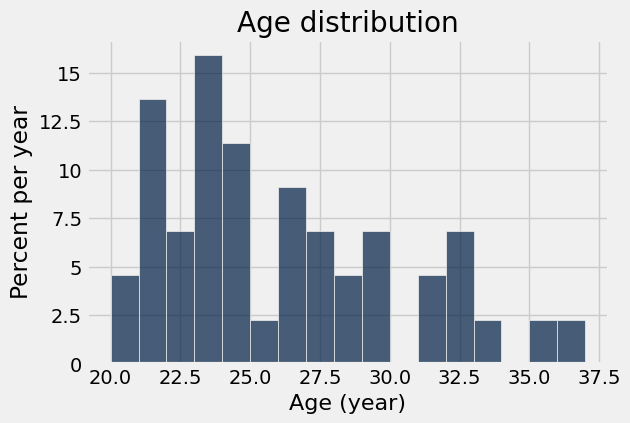

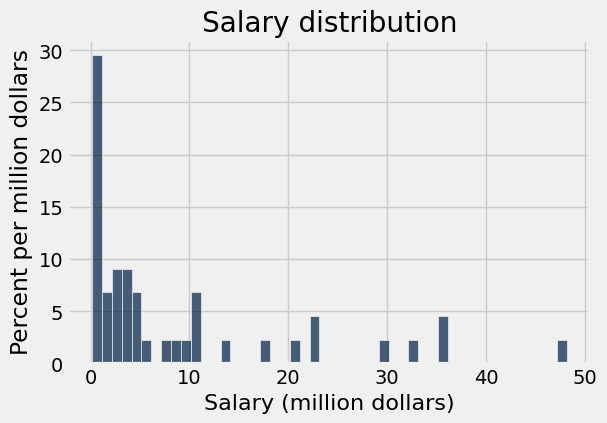

In [59]:
my_small_srswor_data = full_data.sample(44, with_replacement= False)
my_small_stats = compute_statistics(my_small_srswor_data)
my_small_stats

<!-- END QUESTION -->

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 4. More Random Sampling Practice

More practice for random sampling using `np.random.choice`.

###  Simulations and For Loops (cont.)

---

**Question 4.1** We can use `np.random.choice` to simulate multiple trials.

Bing and Mia decide to play a game together rolling a standard six-sided die. Their score on each roll is determined by the face that is rolled. They want to know what their **total score** would be if they rolled the die 1000 times. Write code that simulates their total score after 1000 rolls.

*Hint:* First decide the possible values you can take in the experiment (point values in this case). Then use `np.random.choice` to simulate Bing and Mia's rolls. Finally, sum up the rolls to get the total score.


In [60]:
possible_point_values = make_array (1, 2 ,3 ,4 ,5 ,6)
num_tosses = 1000
simulated_tosses = np.random.choice(possible_point_values, num_tosses)
total_score = simulated_tosses.sum()
total_score

3587

In [61]:
grader.check("q41")

q41 results: All test cases passed!

### Simple random sampling (cont.)

---

**Question 4.2** As in the previous question, analyze several simple random samples of size 100 from `full_data` by using the `compute_statistics` function.  
- Do the histogram shapes seem to change more or less across samples of 100 than across samples of size 44?  
- Are the sample averages and histograms closer to their true values/shape for age or for salary?  What did you expect to see?

_Type your answer here, replacing this text._

<!-- BEGIN QUESTION -->



array([  2.58200000e+01,   9.87297648e+06])

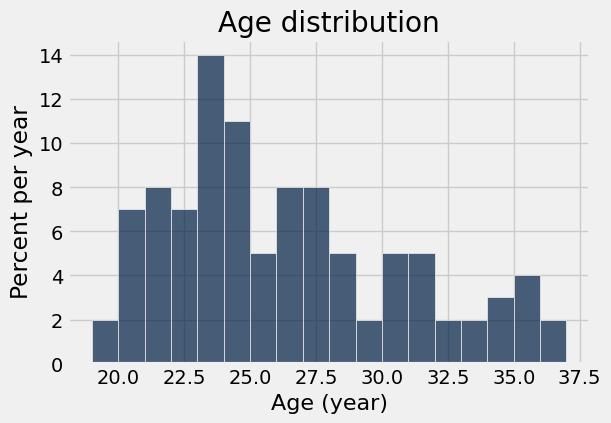

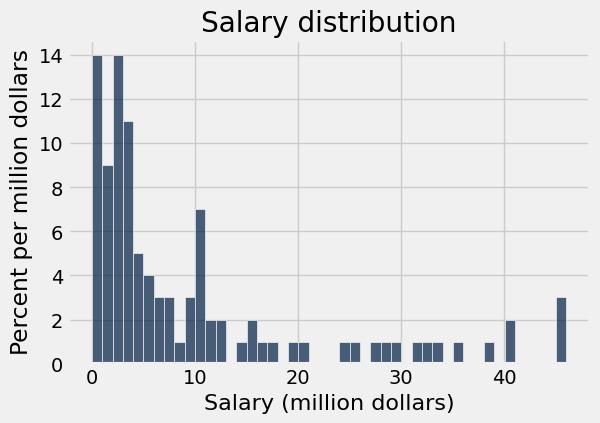

In [62]:
my_large_srswor_data = full_data.sample(100, with_replacement=False)
my_large_stats = compute_statistics(my_large_srswor_data)
my_large_stats

<!-- END QUESTION -->

---

<img src="winnie.png" alt="Picture of an adorable dog named Winnie" width="300"/>

<img src="winnie2.jpeg" alt="Another picture of an adorable dog named Winnie" width="300"/>

**Winnie** is very happy that you finished the lab! Here's two pictures as congratulations!


---

You're done with lab!

**Important submission information:**
- **Run all the tests** and verify that they all pass
- **Save** from the **File** menu
- **Run the final cell to generate the zip file**
- **Click the link to download the zip file**
- Then, go to [Gradescope](https://www.gradescope.com/courses/835871) and submit the zip file to the corresponding assignment. The name of this assignment is "Lab XX Autograder", where XX is the lab number -- 01, 02, 03, etc.

- If you finish early in Regular Lab, **ask one of the staff members to check you off**.

**It is your responsibility to make sure your work is saved before running the last cell.**


## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [63]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False, run_tests=True)

Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    q11 results: All test cases passed!

    q12 results: All test cases passed!

    q13 results: All test cases passed!

    q14 results: All test cases passed!

    q15 results: All test cases passed!

    q21 results: All test cases passed!

    q22 results: All test cases passed!

    q31 results: All test cases passed!

    q41 results: All test cases passed!
